In [5]:
# download the names.txt file from github
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-05-22 22:55:08--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt.2’

names.txt.2         100%[===================>] 222.80K  --.-KB/s    in 0.02s   

2026-05-22 22:55:08 (13.1 MB/s) - ‘names.txt.2’ saved [228145/228145]



In [6]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()

In [7]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [8]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [9]:
from sklearn.manifold import TSNE

In [10]:
random.seed(42)
torch.manual_seed(42)

In [11]:
ctx_len = 4
X, Y = [], []

random.shuffle(words)

for w in words:
  w = '.' * ctx_len + w + '.'
  # ....0123
  for i in range(len(w) - ctx_len):
    x = [stoi[c] for c in w[i:i+ctx_len]]
    y = stoi[w[i+ctx_len]]
    X.append(x)
    Y.append(y)

n_train = int(0.8*len(X))
n_dev = int(0.1*len(X))

X_train, Y_train = torch.tensor(X[:n_train]), torch.tensor(Y[:n_train])
X_dev, Y_dev = X[n_train:n_train+n_dev], Y[n_train:n_train+n_dev]
X_test, Y_test = X[n_train+n_dev:], Y[n_train+n_dev:]

In [12]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.W = torch.randn((fan_in, fan_out))
    self.b = None
    if bias:
      self.b = torch.zeros(fan_out)

  def __call__(self, x):
    self.out =  x @ self.W
    if self.b is not None:
      self.out += self.b;
    return self.out

  def parameters(self):
    return [self.W] + ([] if self.b is None else [self.b])

class BatchNorm:
  def __init__(self, dim, eval=True):
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    self.training = True

    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    if self.training:
      xmean = x.mean(0, keepdim=True)
      xvar = x.var(0, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    h = (x - xmean) / torch.sqrt(xvar + 0.0005)
    self.out = self.gamma * h + self.beta

    if self.training:
      with torch.no_grad():
        self.running_mean = (0.999) * self.running_mean + 0.001 * xmean
        self.running_var = (0.999) * self.running_var + 0.001 * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]


class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []


In [13]:
emb_dim = 10
layer1_size = 200
layer2_size = 300

# Embedding Table
C = torch.randn(vocab_size, emb_dim)  # (27, 10)

layers = [
    Linear(ctx_len * emb_dim, layer1_size, bias=False),
    BatchNorm(layer1_size),
    Tanh(),
    Linear(layer1_size, layer2_size, bias=False),
    BatchNorm(layer2_size),
    Tanh(),
    Linear(layer2_size, vocab_size, bias=False),
    BatchNorm(vocab_size)
]

parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
  p.requires_grad = True

with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1

In [14]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []
grads_mean = []
grads_std = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, X_train.shape[0], (batch_size,))
  Xb, Yb = X_train[ix], Y_train[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(-1, ctx_len * emb_dim) # concatenate the vectors
  for layer in layers:
    x = layer(x)
    # Call retain_grad() on Tanh layer outputs immediately after computation
    if isinstance(layer, Tanh):
      layer.out.retain_grad()
  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    grads_mean.append([layer.out.grad.mean() for layer in layers if isinstance(layer, Tanh)] )
    grads_std.append([layer.out.grad.std() for layer in layers if isinstance(layer, Tanh)] )
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

      0/ 200000: 3.3207
  10000/ 200000: 2.5583
  20000/ 200000: 2.1909
  30000/ 200000: 2.2123
  40000/ 200000: 2.2102
  50000/ 200000: 2.2748
  60000/ 200000: 2.2654
  70000/ 200000: 2.1371
  80000/ 200000: 2.0560
  90000/ 200000: 2.3208
 100000/ 200000: 2.3080
 110000/ 200000: 2.0524
 120000/ 200000: 1.9364
 130000/ 200000: 2.3272
 140000/ 200000: 2.1497
 150000/ 200000: 1.9428
 160000/ 200000: 2.3945
 170000/ 200000: 1.8916
 180000/ 200000: 2.1221
 190000/ 200000: 2.4434


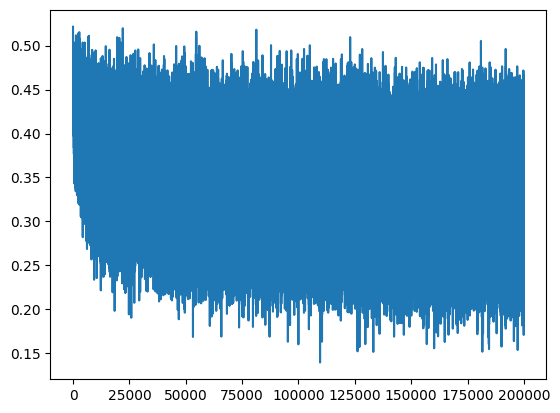

In [15]:
plt.plot(lossi)

layer 2 (      Tanh): mean -0.03, std 0.65, saturated: 2.83%
layer 5 (      Tanh): mean +0.02, std 0.68, saturated: 4.67%


/tmp/ipykernel_35666/530501210.py:6: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.99).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

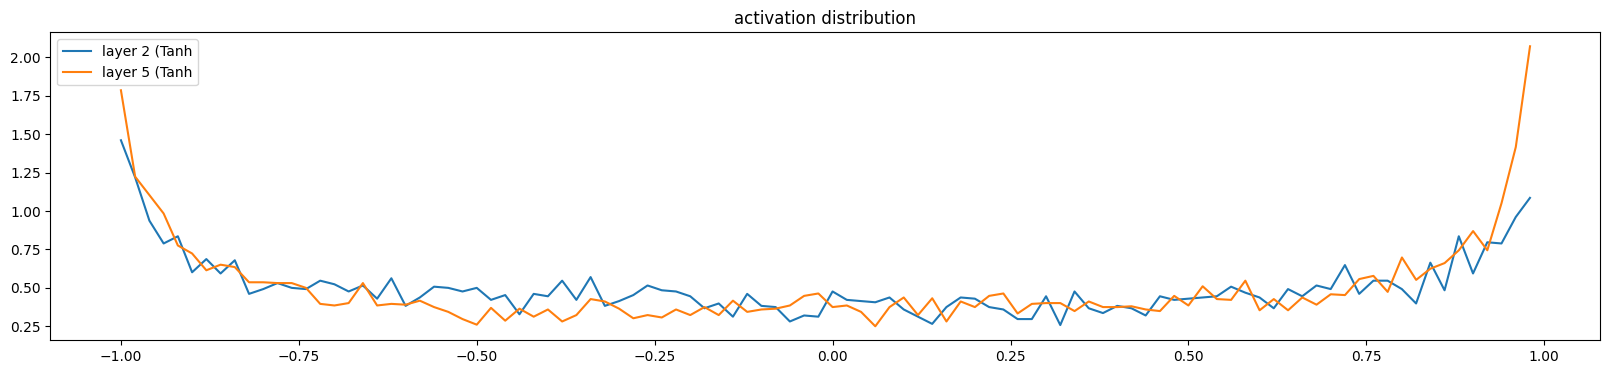

In [16]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers):
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.99).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.000000, std 5.359500e-03
layer 5 (      Tanh): mean +0.000000, std 3.927269e-03


Text(0.5, 1.0, 'gradient distribution')

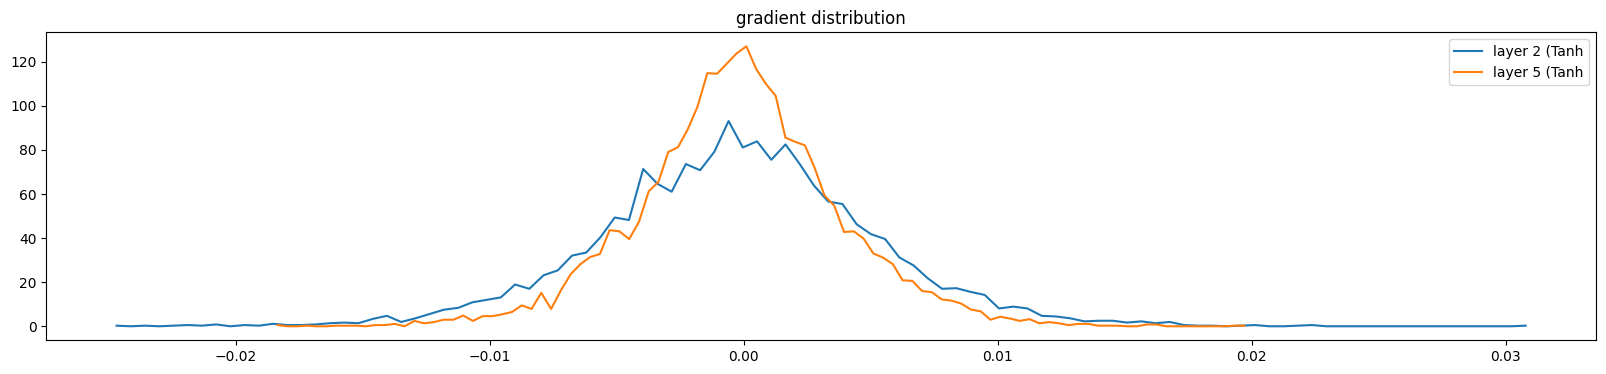

In [17]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers):
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

Text(0.5, 1.0, 'Mean gradient distribution over training steps for Tanh layers')

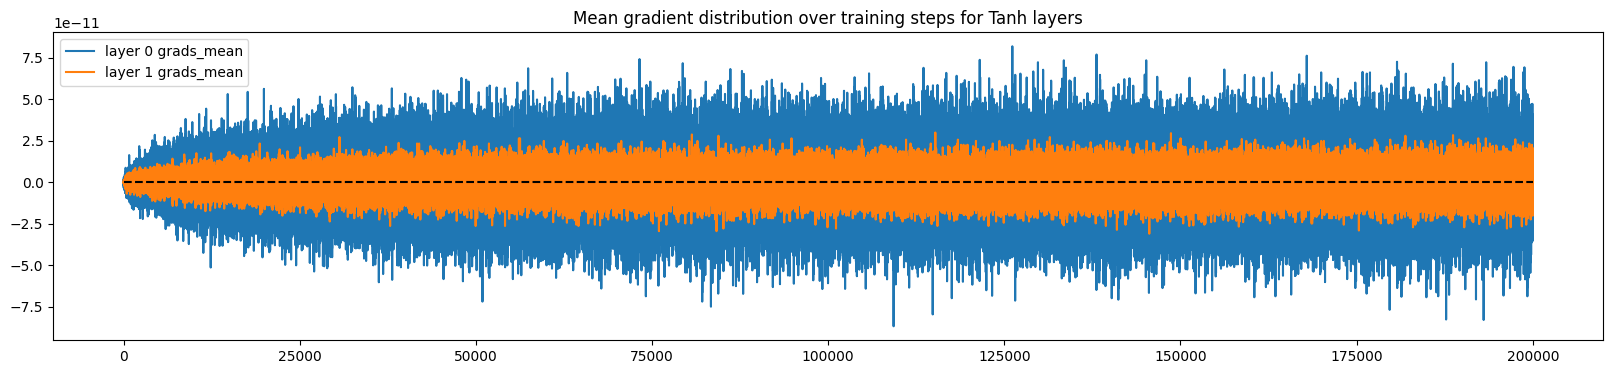

In [23]:
plt.figure(figsize=(20, 4))
legends = []

# Assuming grads_mean is not empty, get the number of Tanh layers
if grads_mean:
    num_tanh_layers = len(grads_mean[0])
else:
    num_tanh_layers = 0 # Handle case where grads_mean might be empty

for j in range(num_tanh_layers):
  # Plot the mean gradient for each Tanh layer over all training steps
  plt.plot([g[j].item() for g in grads_mean])
  legends.append(f'layer {j} grads_mean')

plt.plot([0, len(grads_mean)], [0, 0], 'k--') # Mean gradients should ideally be around 0
plt.legend(legends);
plt.title('Mean gradient distribution over training steps for Tanh layers')

Text(0.5, 1.0, 'Std gradient distribution over training steps for Tanh layers')

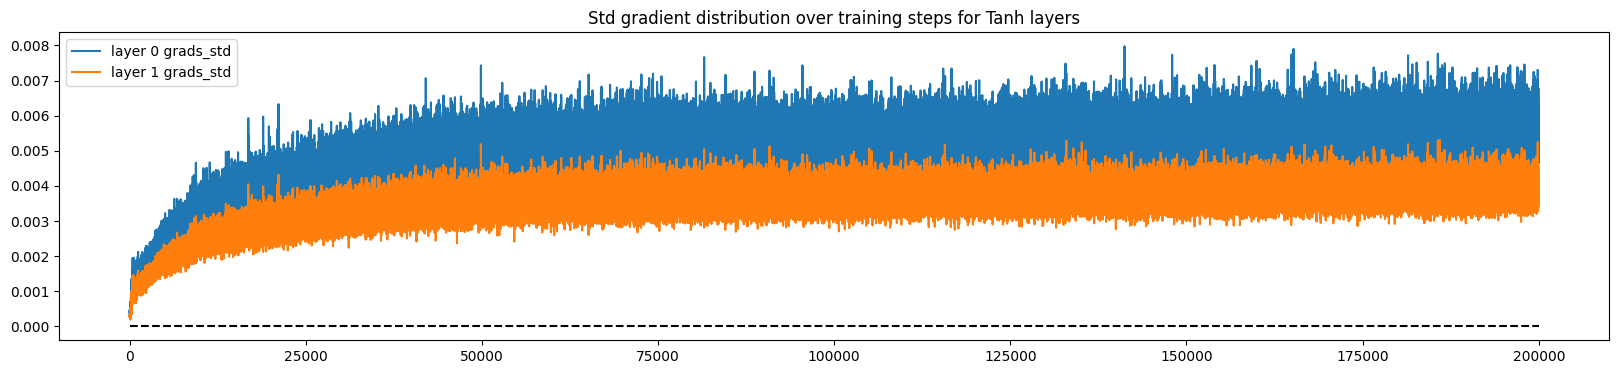

In [24]:
plt.figure(figsize=(20, 4))
legends = []

# Assuming grads_mean is not empty, get the number of Tanh layers
if grads_mean:
    num_tanh_layers = len(grads_std[0])
else:
    num_tanh_layers = 0 # Handle case where grads_mean might be empty

for j in range(num_tanh_layers):
  # Plot the mean gradient for each Tanh layer over all training steps
  plt.plot([g[j].item() for g in grads_std])
  legends.append(f'layer {j} grads_std')

plt.plot([0, len(grads_mean)], [0, 0], 'k--') # Mean gradients should ideally be around 0
plt.legend(legends);
plt.title('Std gradient distribution over training steps for Tanh layers')

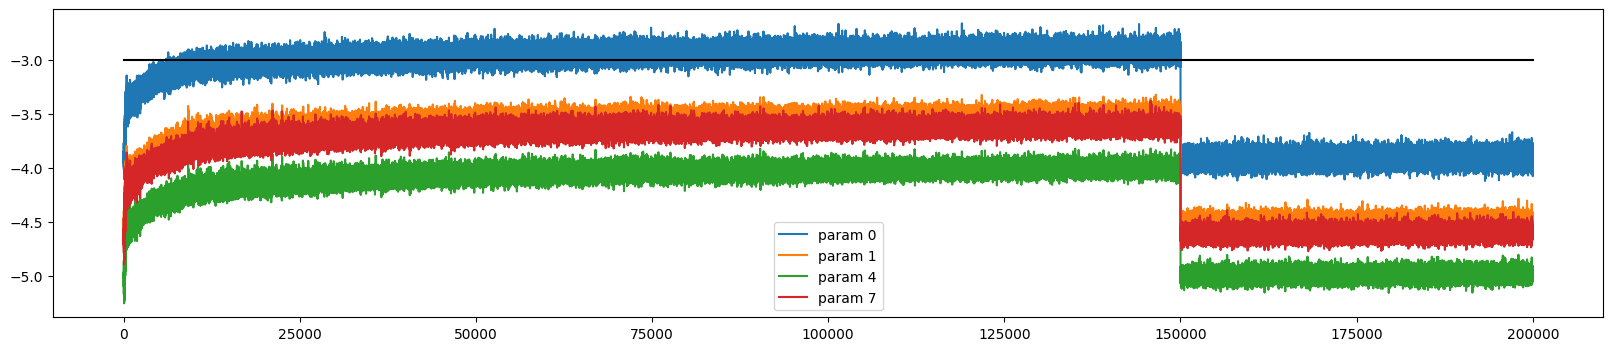

In [20]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [25]:
cnt = 20

# Set all BatchNorm layers to evaluation mode
# This makes them use running_mean and running_var instead of batch statistics
for layer in layers:
    if isinstance(layer, BatchNorm):
        layer.training = False

for _ in range(cnt):
  out_str = ""
  inp = '.' * (ctx_len - min(ctx_len, len(out_str))) + out_str
  while True:
    idx = [stoi[c] for c in inp[-ctx_len:]]
    emb = C[idx]
    x = emb.view(-1, ctx_len * emb_dim) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    probs = F.softmax(x, dim=1)

    idx = torch.multinomial(probs, num_samples=1).item()
    char = itos[idx]

    if char == '.':
      break

    inp += char
    out_str += char

  print(out_str)

lazhyleh
navuau
parrali
laco
bagekxn
kalayshalena
ashlie
thahtie
smer
traygo
ovani
ozia
bayel
fren
natrielle
denya
beok
biklaegei
abdorshith
elivabella
